In [ ]:
data = [
    {'grade': 85, 'siblings': 4, 'subject': 'math'},
    {'grade': 70, 'siblings': 3, 'subject': 'english'},
    {'grade': 65, 'siblings': 3, 'subject': 'math'},
    {'grade': 60, 'siblings': 2, 'subject': 'physics'}
]

In [ ]:
from sklearn.feature_extraction import DictVectorizer
vec = DictVectorizer()
vec.fit_transform(data).toarray()

array([[85.,  4.,  0.,  1.,  0.],
       [70.,  3.,  1.,  0.,  0.],
       [65.,  3.,  0.,  1.,  0.],
       [60.,  2.,  0.,  0.,  1.]])

In [ ]:
vec.get_feature_names_out()

array(['grade', 'siblings', 'subject=english', 'subject=math',
       'subject=physics'], dtype=object)

In [ ]:
data2 = [
    'weather is good',
    'good person',
    'weather is bad'
]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer()
X=vec.fit_transform(data2)
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (3, 5)>

In [ ]:
import pandas as pd
pd.DataFrame(X.toarray(),columns=vec.get_feature_names_out())

,bad,good,is,person,weather
0,0,1,1,0,1
1,0,1,0,1,0
2,1,0,1,0,1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

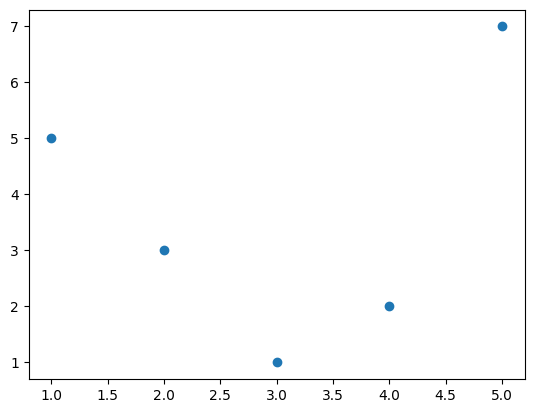

In [ ]:
x=np.array([1,2,3,4,5])
y=np.array([5,3,1,2,7])
plt.scatter(x,y)

In [ ]:
from sklearn.linear_model import LinearRegression
X=x[:,np.newaxis]
model = LinearRegression().fit(X,y)

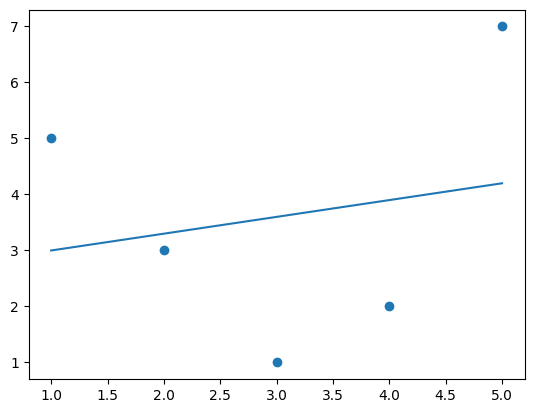

In [ ]:
y_fit=model.predict(X)
plt.scatter(x,y)
plt.plot(x,y_fit)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3,include_bias=False)

In [ ]:
X2=poly.fit_transform(X)
X2

array([[  1.,   1.,   1.],
       [  2.,   4.,   8.],
       [  3.,   9.,  27.],
       [  4.,  16.,  64.],
       [  5.,  25., 125.]])

In [ ]:
model=LinearRegression().fit(X2,y)
y_fit=model.predict(X2)

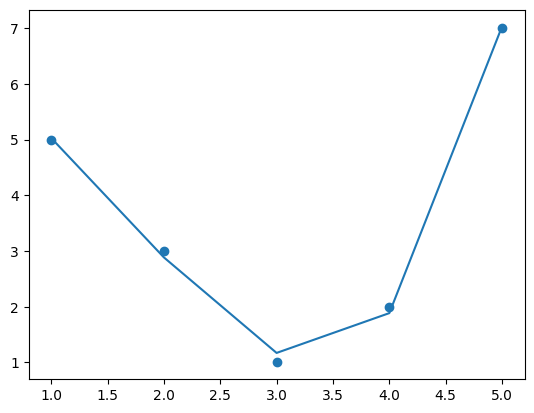

In [ ]:
plt.scatter(x,y)
plt.plot(x,y_fit)

In [ ]:
from numpy import nan
X=np.array([[1,nan,3],[5,6,9],[4,5,nan],[9,8,8]])
y=np.array([10,2,-2,4])

In [ ]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='mean')
X2=imp.fit_transform(X)
X2

array([[1.        , 6.33333333, 3.        ],
       [5.        , 6.        , 9.        ],
       [4.        , 5.        , 6.66666667],
       [9.        , 8.        , 8.        ]])

In [ ]:
model=LinearRegression().fit(X2,y)
model.predict(X2)

array([10.,  2., -2.,  4.])

In [ ]:
from sklearn.pipeline import make_pipeline
model=make_pipeline(SimpleImputer(strategy='mean'), PolynomialFeatures(degree=2), LinearRegression())
model.fit(X,y)
print(y)
print(model.predict(X))

[10  2 -2  4]
[10.  2. -2.  4.]
